In [ ]:
''' NOTES/TO DO:
1. normalize input/output? 
2. add more upsampling (to improve smoothing)
3. add CRPS loss function and two channels on output
4. change prediction to the difference between cesm prediction and truth?
'''

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import copy
import os

import sys
sys.path.append('/glade/work/kjmayer/research/catalyst/ViT_XAI/Models/S2Sbiascorr/utils')
from visiontransformer import VisionTransformer

# Data and Compute Prep:

In [2]:
doDask = False
if doDask:
    print('...setting up dask client...')
    if 'client' in locals():
        client.shutdown()
        print('...shutdown client...')
    else:
        print('client does not exist yet')

    # ### ++++++ dask NCAR client: 
    from distributed import Client
    from dask_jobqueue import PBSCluster
    project_num = 'P03010039' #'P03010039' #what project key do you have? 
    
    cluster = PBSCluster(account=project_num,
                         walltime='12:00:00',
                         cores=1,
                         memory='40GB',
                         shared_temp_directory='/glade/derecho/scratch/kjmayer/tmp',
                         queue='casper')
    cluster.scale(jobs=40)
    client = Client(cluster)
    print(client) 

print(torch.cuda.is_available())

def set_gpu(gpu_id):
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_id)
    
gpu_id=0

# if gpu_id >= 0:
#     device = "cuda"
#     set_gpu(gpu_id)
#     print('device available :', torch.cuda.is_available())
#     print('device count: ', torch.cuda.device_count())
#     print('current device: ',torch.cuda.current_device())
#     print('device name: ',torch.cuda.get_device_name())
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# else:
device = torch.device('cuda')

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

print('using device: ', device)

True
NVIDIA A100-SXM4-80GB
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB
using device:  cuda


# LOAD & PREP DATA

## Load the Data

In [3]:
ddir = '/glade/derecho/scratch/kjmayer/DATA/CESM2-S2S/'

X_finames = ['tas_2m_anom_cesm2cam6v2_04jan1999-28dec2020_00z_initmean_m00-10mean.nc',
             'tas_2m_anom_cesm2cam6v2_04jan1999-28dec2020_00z_week12mean_m00-10mean.nc',
             'tas_2m_anom_cesm2cam6v2_04jan1999-28dec2020_00z_week34mean_m00-10mean.nc',
             'tas_2m_anom_cesm2cam6v2_04jan1999-28dec2020_00z_week56mean_m00-10mean.nc']
Y_finames = ['tas_2m_anom_ERA5_04jan1999-28dec2020_week12mean.nc',
             'tas_2m_anom_ERA5_04jan1999-28dec2020_week34mean.nc',
             'tas_2m_anom_ERA5_04jan1999-28dec2020_week56mean.nc']

Xinit = xr.open_dataset(ddir+X_finames[0])['tas_2m']
X12 = xr.open_dataset(ddir+X_finames[1])['tas_2m']
X34 = xr.open_dataset(ddir+X_finames[2])['tas_2m']
X56 = xr.open_dataset(ddir+X_finames[3])['tas_2m']

Y12 = xr.open_dataset(ddir+Y_finames[0])['tas_2m']
Y34 = xr.open_dataset(ddir+Y_finames[1])['tas_2m']
Y56 = xr.open_dataset(ddir+Y_finames[2])['tas_2m']


Xind12 = xr.DataArray(np.full(len(X12), 0),
                      dims='init',
                      coords={'init': X12.init})

Xind34 = xr.DataArray(np.full(len(X34), 1),
                      dims='init',
                      coords={'init': X34.init})

Xind56 = xr.DataArray(np.full(len(X56), 2),
                      dims='init',
                      coords={'init': X56.init})


In [27]:
Xinits = xr.concat([Xinit, Xinit, Xinit],dim='init')
Xweeks = xr.concat([X12, X34, X56], dim='init')
Xindweeks = xr.concat([Xind12, Xind34, Xind56], dim='init')

Xall = xr.concat([Xinits, Xweeks, Xindweeks], dim='feature').transpose("init", "feature", "lat", "lon")
Xall = Xall[:,:,1:,:] # make lat dimension 180 instead of 181 by removing -90
Yall = xr.concat([Y12, Y34, Y56], dim='init')
Yall = Yall[:,1:,:] # make lat dimension 180 instead of 181 by removing -90

In [28]:
# train, val, test split
Ntrain = 1000
Nval = 500

Xtrain = Xall[:Ntrain].values
Xval = Xall[Ntrain:Ntrain+Nval].values
Ytrain = Yall[:Ntrain].values
Yval = Yall[Ntrain:Ntrain+Nval].values

# TRAINING

## Data Loader

In [29]:
class SpatialDataset(Dataset):
    def __init__(self, X, y):
        # X = [features, samples, lat, lon]
        # Y = [samples, lat, lon]
        randi = np.random.choice(range(np.shape(X)[0]),size=np.shape(X)[0])
        self.X = torch.nan_to_num(torch.tensor(X[randi], dtype=torch.float32))
        self.y = torch.nan_to_num(torch.tensor(y[randi], dtype=torch.float32))

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx].unsqueeze(0)

## Model

In [30]:
D_MODEL = 256 # patch_width * patch_height * num_channels is converted into size of d_model
N_CLASSES = 10
IMG_SIZE = Xtrain.shape[-2:]
PATCH_SIZE = (10, 10)
N_CHANNELS = 3
N_HEADS = 1
N_LAYERS = 3
BATCH_SIZE = 64
EPOCHS = 5
ALPHA = 0.005
LR = 0.001
PATIENCE = 3
INPUT_SIZE = np.shape(Xtrain)
DECODER_CONFIG = {"filters": [32, 1],
                  "act_func": ["Linear"],
                  "padding": [(0,0)],
                  "output_padding": [(0,0)],
                  "kernel_size": [(10,10)],
                  "stride": (10,10)}

# OUTPUT_DIM = 1
# WIDTH, LAYERS = 4, 2
# MLP_RATIO = 1


model = VisionTransformer(d_model=D_MODEL,
                          n_classes=N_CLASSES,
                          img_size=IMG_SIZE,
                          patch_size=PATCH_SIZE,
                          n_channels=N_CHANNELS,
                          n_heads=N_HEADS,
                          n_layers=N_LAYERS,
                          decoder_config=DECODER_CONFIG)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),
                       lr=LR,
                       weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 mode='max',
                                                 factor=0.1,
                                                 patience=PATIENCE,
                                                 verbose=True)

train_dataset = SpatialDataset(Xtrain, Ytrain)
val_dataset = SpatialDataset(Xval, Yval)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [31]:
model = model.to(device)
num_epochs = 30
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    print(f"Starting Epoch {epoch}")
    nsampsseen = 0
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        nsampsseen += inputs.shape[0]
        if nsampsseen > 100000:
            break
    epoch_loss = running_loss / nsampsseen
    print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}")

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    mse_val_batch = []
    labels_full = []
    outputs_full = []
    with torch.no_grad():  # In validation phase, we don't need to compute gradients
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs.to(device))
            mse_val_batch.append((torch.mean((outputs-labels)**2)))
            labels_full.append(labels)
            outputs_full.append(outputs)
    # Calculate and print validation accuracy
    mse_tot = torch.mean(torch.tensor(mse_val_batch))
    
    if epoch == 0:
        print('...saved first epoch...')
        best_mod = copy.deepcopy(model)
        best_loss = copy.deepcopy(mse_tot)
    elif mse_tot<best_loss:
        print('...saving!...')
        best_mod = copy.deepcopy(model)
        best_loss = copy.deepcopy(mse_tot)
    else:
        print('No improvement in validation accuracy.')
    # Step the scheduler on each epoch
    scheduler.step(mse_tot)

Starting Epoch 0
Epoch 0, Loss: 2.4816
...saved first epoch...
Starting Epoch 1
Epoch 1, Loss: 2.2054
...saving!...
Starting Epoch 2
Epoch 2, Loss: 2.1728
No improvement in validation accuracy.
Starting Epoch 3
Epoch 3, Loss: 2.1591
No improvement in validation accuracy.
Starting Epoch 4
Epoch 4, Loss: 2.1460
...saving!...
Epoch 00005: reducing learning rate of group 0 to 1.0000e-04.
Starting Epoch 5
Epoch 5, Loss: 2.1315
...saving!...
Starting Epoch 6
Epoch 6, Loss: 2.1275
...saving!...
Starting Epoch 7
Epoch 7, Loss: 2.1254
...saving!...
Starting Epoch 8
Epoch 8, Loss: 2.1234
...saving!...
Epoch 00009: reducing learning rate of group 0 to 1.0000e-05.
Starting Epoch 9
Epoch 9, Loss: 2.1214
No improvement in validation accuracy.
Starting Epoch 10
Epoch 10, Loss: 2.1212
No improvement in validation accuracy.
Starting Epoch 11
Epoch 11, Loss: 2.1209
No improvement in validation accuracy.
Starting Epoch 12
Epoch 12, Loss: 2.1207
No improvement in validation accuracy.
Epoch 00013: reducing

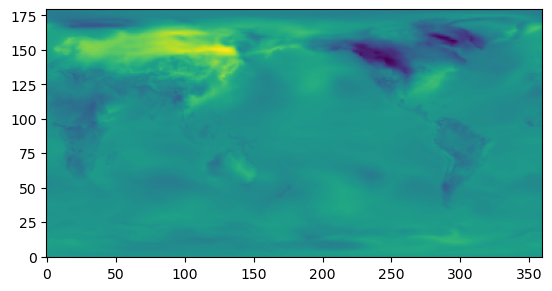

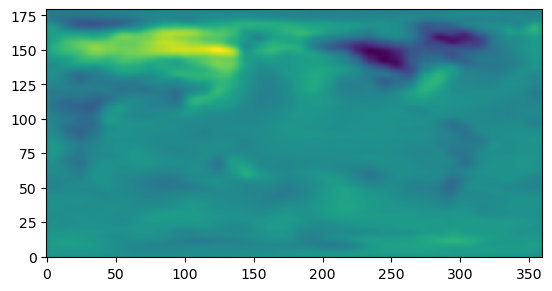

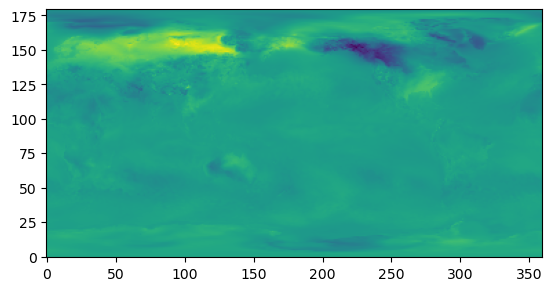

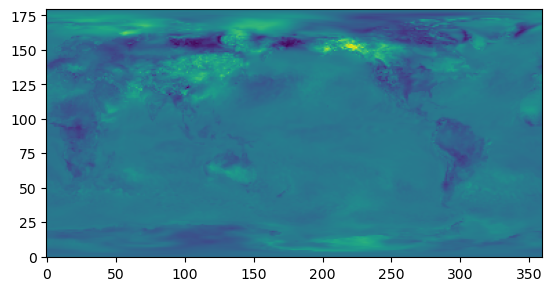

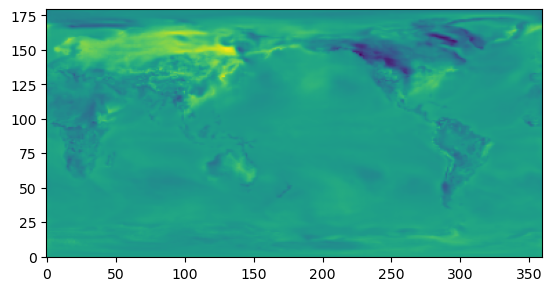

In [35]:
labels_full = []
outputs_full = []
acc_val_batch = []
with torch.no_grad():  # In validation phase, we don't need to compute gradients
    for inputs, labels in val_loader:
        inputs = inputs.to(device).cpu()
        labels = labels.to(device).cpu()
        outputs = best_mod(inputs.to(device)).cpu()
        plt.imshow(inputs[0,1],origin='lower')
        plt.show()
        plt.imshow(outputs[0].squeeze(),origin='lower')
        plt.show()
        plt.imshow(labels[0].squeeze(),origin='lower')
        plt.show()

        plt.imshow((inputs[0,1] - labels[0].squeeze()),origin='lower')
        plt.show()

        plt.imshow((inputs[0,1] - outputs[0].squeeze()),origin='lower')
        plt.show()
        
        break

In [38]:
print((inputs[0,1] - labels[0].squeeze()).mean())

print((inputs[0,1] - outputs[0].squeeze()).mean())

tensor(-0.1808)
tensor(0.1281)


In [ ]:
batch_size = 64
input_shape = (1, 1, 192, 288) # Example input shape (C, H, W)


#(self, img_size=224, patch_size=16, in_chans=3, num_classes=1000, embed_dim=768, depth=12,num_heads=12, mlp_ratio=4., qkv_bias=False, mlp_head=False, drop_rate=0., attn_drop_rate=0.):

model = svitl.VisionTransformer(
        image_lr = 192,
        image_ud = 288,
        patch_size = 16,
        num_classes = 1,
        in_chans = 1,
        embed_dim = 3,
        depth = 2,
        num_heads = 3,
        mlp_ratio = 2.,
    ).to(device)



criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

train_dataset = SpatialDataset(np_arr_x_train_anom, np_arr_y_train_anom )
val_dataset = SpatialDataset(np_arr_x_val_anom, np_arr_y_val_anom)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)